# Run BiSSGL

In [1]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [2]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/realAnalysis/tuberculosis/")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [3]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_bissgl.gz"}

In [4]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [5]:
from sgimc.utils import mc_split

In [6]:
from sgimc.utils import get_submatrix

In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sgimc.utils import sparsify_with_mask


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [8]:
random_state = np.random.RandomState(0x0BADCAFE)

In [72]:
from sgimc.utils import load, save

U, V, Y = load(filename_input)
Y[Y == -1] = 0  # transfer Y from {-1, 1} to {0, 1}.

In [10]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

In [83]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": np.arange(0.01, 0.1, 0.02),
        "n_splits": [3],
    }
)

grid_model = ParameterGrid(
    {
        "tilde_lambda0": [1, 3, 5],
        "lambda0": [1, 3, 5],
        "xi": [1, 2, 3, 5, 10],
        "eta": [1e-6, 1e-8],
        "K": [3, 6, 13],
    }
)

In [84]:
import sys

sys.path.append(PATH_ROOT)

from scripts.methods.BiSSGL.BiSSGLc import BiSSGL

In [ ]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        # set up the model
        xi, eta, tilde_lambda0, lambda0, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["lambda0"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=1,
            tilde_alpha=1 / K,
            tilde_beta=1,
            lambda0=lambda0,
            lambda1=1,
            alpha=1 / K,
            beta=1,
            K=K,
            max_iter=1000,
            tol=1e-8,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(Y_test, prob_test)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # run the k-fold CV
        # splt = ShuffleSplit(**par_dtst, random_state=random_state)
        splt = KFold(par_dtst["n_splits"], shuffle=True, random_state=random_state)
        for cv, (ind_train, ind_valid) in enumerate(splt.split(ind_train_all)):

            # prepare the train and test indices
            ind_train, ind_valid = ind_train_all[ind_train], ind_train_all[ind_valid]
            Y_train = get_submatrix(Y, ind_train)
            Y_valid = get_submatrix(Y, ind_valid)

            # fit the model
            model = BiSSGL(
                Y=Y_train.toarray(),
                U=U,
                V=V,
                xi=xi,
                eta=eta,
                tilde_lambda0=tilde_lambda0,
                tilde_lambda1=1,
                tilde_alpha=1 / K,
                tilde_beta=1,
                lambda0=lambda0,
                lambda1=1,
                alpha=1 / K,
                beta=1,
                K=K,
                max_iter=1000,
                tol=1e-8,
            )

            # fit on the cv dataset
            est_mu, est_A, est_B, logLik = model.optimization()

            # compute the class probabilities
            prob_full = expit(U @ est_A @ est_B.T @ V.T)
            prob_valid = get_submatrix(prob_full, ind_valid)
            scores_valid = mc_get_scores(Y_valid, prob_valid)
            d1_valid = sum(abs(est_A).max(axis=1) > 0)
            d2_valid = sum(abs(est_B).max(axis=1) > 0)

            # record the results
            results.append(
                {
                    "train_size": par_dtst["train_size"],
                    "xi": par_mdl["xi"],
                    "eta": par_mdl["eta"],
                    "tilde_lambda0": par_mdl["tilde_lambda0"],
                    "lambda0": par_mdl["lambda0"],
                    "K": par_mdl["K"],
                    "cv": cv,
                    "val_score": scores_valid["auc"],
                    "val_d1": d1_valid,
                    "val_d2": d2_valid,
                    "test_score": scores_test["auc"],
                    "test_d1": d1_test,
                    "test_d2": d2_test,
                }
            )
        # end for
    # end for
# end for

# Save the results in a pickle

with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

  0%|          | 0/5 [00:00<?, ?it/s]

Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999
Finished with iterations of 999


In [82]:
xi, eta, tilde_lambda0, lambda0, K

(1, 1e-05, 1, 1, 3)

In [17]:
filename_output

'/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz'

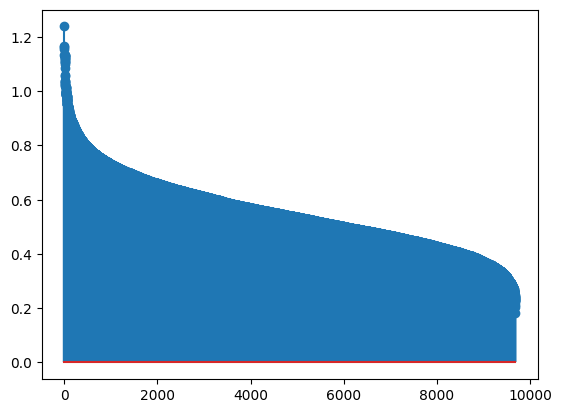

In [116]:
plt.stem(sorted(abs(est_A).max(axis=1), reverse=True))
plt.show()

In [34]:
from collections import defaultdict


def get_final_results(results, param="train_size", hyp_param="C_group"):
    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # averaging the cross-validation results
    results_avg = []

    for ids in id_groups:
        val_res = [id_result[_id] for _id in ids]
        avg_res = np.mean(val_res, axis=0)
        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2, 3]]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    return results_final.T

In [28]:
filename_results = "/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/archived/20251224_220613results_bissgl.gz"

In [35]:
PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

for fn in os.listdir(PATH_ARCHIVE):
    filename_results.append(os.path.join(PATH_ARCHIVE, fn))

In [36]:
filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz',
 '/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/archived/20251224_220613results_bissgl.gz']

In [ ]:
results.append(
    load(
        "/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/archived/20251224_220613results_bissgl.gz"
    )
)

In [39]:
results = []
for fn in filename_results[1:1]:
    results.append(load(fn))

In [69]:
results

[[{'train_size': 0.001,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 1.5,
   'lambda0': 1.5,
   'K': 13,
   'cv': 0,
   'val_score': 0.9464285714285715,
   'test_score': 0.6868084360307896},
  {'train_size': 0.001,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 1.5,
   'lambda0': 1.5,
   'K': 13,
   'cv': 1,
   'val_score': 1.0,
   'test_score': 0.6868084360307896},
  {'train_size': 0.001,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 1.5,
   'lambda0': 1.5,
   'K': 13,
   'cv': 2,
   'val_score': 1.0,
   'test_score': 0.6868084360307896},
  {'train_size': 0.001,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 1.5,
   'lambda0': 1.5,
   'K': 13,
   'cv': 3,
   'val_score': 1.0,
   'test_score': 0.6868084360307896},
  {'train_size': 0.001,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 1.5,
   'lambda0': 1.5,
   'K': 13,
   'cv': 4,
   'val_score': 1.0,
   'test_score': 0.6868084360307896},
  {'train_size': 0.001,
   'xi': 10,
   'eta': 1e-06,
   'tilde_lambda0': 1.5,
   'la

In [ ]:
results_final = []
for result in results:
    results_final.append(get_final_results(result, param="xi", hyp_param="train_size"))
results_final = np.array(results_final)
results_bissgl = np.mean(results_final, axis=0)

In [66]:
print(results_final, "\n", results_bissgl)

[[[ 1.         10.        ]
  [ 0.73192378  0.63488379]]] 
 [[ 1.         10.        ]
 [ 0.73192378  0.63488379]]


In [67]:
import matplotlib.lines as mlines

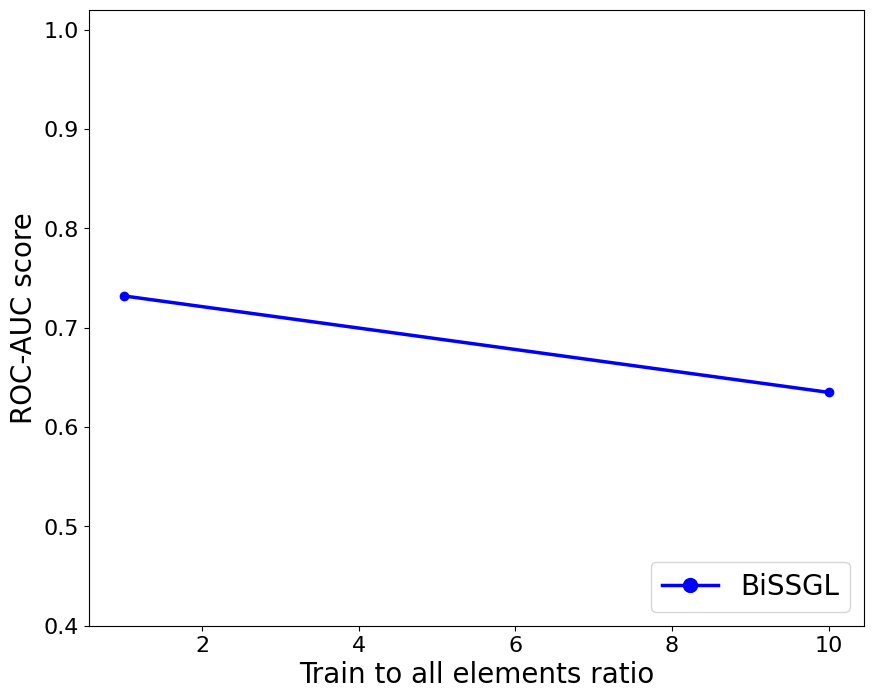

In [68]:
plt.figure(figsize=(10, 8))

# lines
bissgl_line = mlines.Line2D(
    [], [], color="blue", marker="o", linewidth=2.5, markersize=10, label="BiSSGL"
)
# imc_line = mlines.Line2D([], [], color='red', marker='s', linewidth=2.5,
#                          markersize=10, label='IMC')
# mf_line = mlines.Line2D([], [], color='green', marker='^', linewidth=2.5,
#                         markersize=10, label='MF')
# sgimc_comb_line = mlines.Line2D([], [], color='blue', marker='o', linewidth=2.5, linestyle='--',
#                                 markersize=10, label='SGIMC-comb')
# imc_comb_line = mlines.Line2D([], [], color='red', marker='s', linewidth=2.5, linestyle='--',
#                               markersize=10, label='IMC-comb')

# curves
plt.plot(results_bissgl[0], results_bissgl[1], "b-", label="SGIMC", linewidth=2.5)
# plt.plot(results_imc[0], results_imc[1], 'r-', label='IMC', linewidth=2.5)
# plt.plot(results_mf[0], results_mf[1], 'g-', label='MF', linewidth=2.5)
# plt.plot(results_bissgl_comb[0], results_bissgl_comb[1], 'b--', label='SGIMC-comb', linewidth=2.5)
# plt.plot(results_imc_comb[0], results_imc_comb[1], 'r--', label='IMC-comb', linewidth=2.5)

# dotes
plt.plot(results_bissgl[0], results_bissgl[1], "bo", label="SGIMC", linewidth=2.5)
# plt.plot(results_imc[0], results_imc[1], 'rs', label='IMC', linewidth=2.5)
# plt.plot(results_mf[0], results_mf[1], 'g^', label='MF', linewidth=2.5)
# plt.plot(results_bissgl_comb[0], results_bissgl_comb[1], 'bo', label='SGIMC-comb', linewidth=2.5)
# plt.plot(results_imc_comb[0], results_imc_comb[1], 'rs', label='IMC-comb', linewidth=2.5)

# specify axis limits and labels
plt.ylim((0.4, 1.02))
plt.xlabel("Train to all elements ratio", fontsize=20)
plt.ylabel("ROC-AUC score", fontsize=20)

# ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# legend
plt.legend(
    handles=[
        bissgl_line,  # imc_line, mf_line, sgimc_comb_line, imc_comb_line
    ],
    fontsize=20,
    loc=4,
)

plt.show()